In [1]:
# Load necessary libraries
library(ggplot2)
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
# 1. Load the data
# (I am creating the dataframe from your provided text snippet here. 
#  Replace this with read.csv("your_file.csv") for your actual data)

df <- read.csv("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Code/GridSearch_Results/pareto_raw_results.csv")


In [3]:
# 2. Reshape Data for Plotting
# We need to separate the data into 3 groups based on which modality weight we are tracking.
# We map alpha -> Expression, beta -> Mutation, gamma -> CNV.

# Extract Expression data (X axis = alpha)
df_exp <- df %>%
  select(Weight = alpha, Loss = total_loss) %>%
  mutate(Modality = "Expression")

# Extract Mutation data (X axis = beta)
df_mut <- df %>%
  select(Weight = beta, Loss = total_loss) %>%
  mutate(Modality = "Mutation")

# Extract CNV data (X axis = gamma)
df_cnv <- df %>%
  select(Weight = gamma, Loss = total_loss) %>%
  mutate(Modality = "CNV")

# Combine them into one plotting dataframe
plot_data <- bind_rows(df_exp, df_mut, df_cnv)

`geom_smooth()` using formula = 'y ~ x'


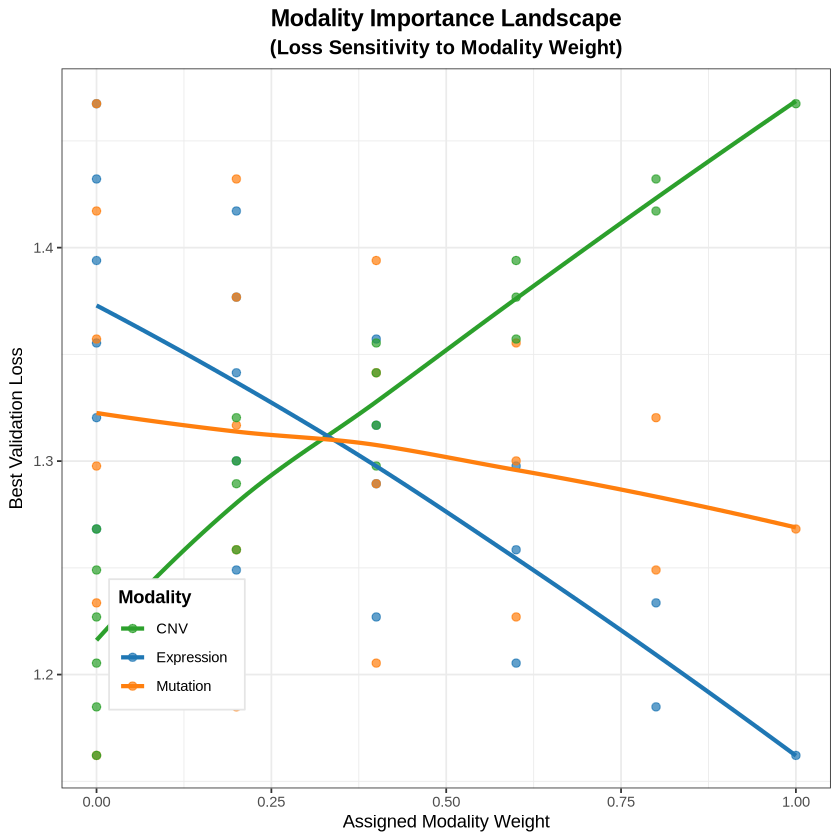

In [4]:
ggplot(plot_data, aes(x = Weight, y = Loss, color = Modality)) +

  # Raw points (keep them so reviewers don’t complain)
  geom_point(size = 2, alpha = 0.7) +

  # Smoothed curve fitting (LOESS)
  geom_smooth(
    method = "loess",
    span = 0.77,       # ↓ smoother curve, ↑ more flexible
    se = FALSE,        # no confidence band (clean look)
    linewidth = 1.2
  ) +

  # Colors matching modality importance style
  scale_color_manual(values = c(
    "Expression" = "#1f77b4",
    "Mutation"   = "#ff7f0e",
    "CNV"        = "#2ca02c"
  )) +

  labs(
    title = "Modality Importance Landscape",
    subtitle = "(Loss Sensitivity to Modality Weight)",
    x = "Assigned Modality Weight",
    y = "Best Validation Loss",
    color = "Modality"
  ) +

  theme_bw() +
  theme(
    plot.title = element_text(face = "bold", size = 14, hjust = 0.5),
    plot.subtitle = element_text(face = "bold", size = 12, hjust = 0.5),
    legend.position = c(0.15, 0.2),
    legend.background = element_rect(fill = "white", color = "gray90"),
    legend.title = element_text(face = "bold")
  )



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Registering fonts with R

`geom_smooth()` using formula = 'y ~ x'


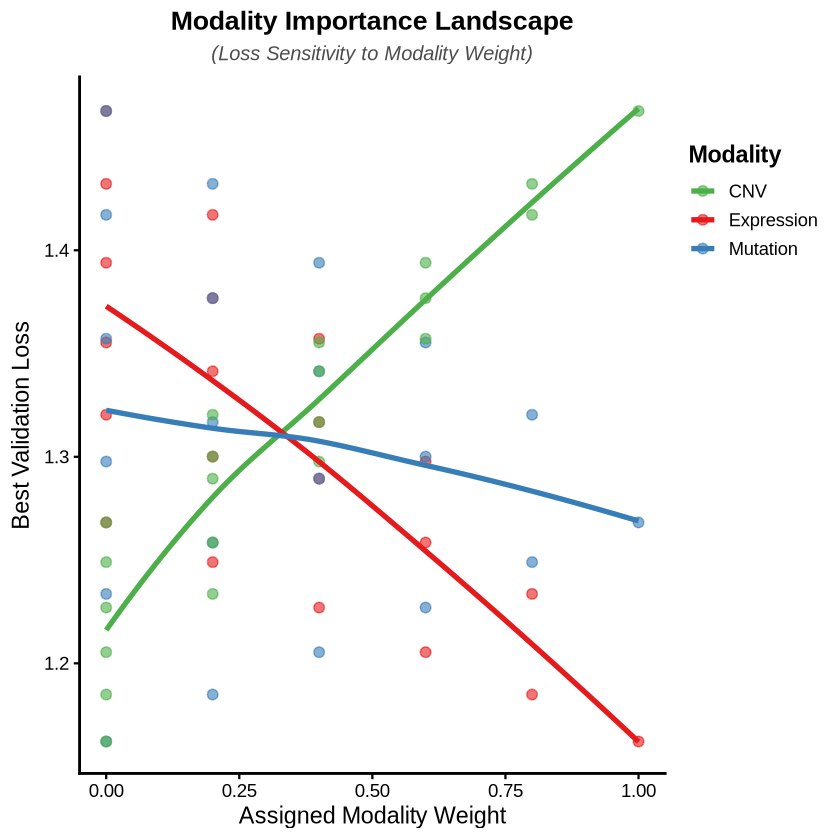

In [1]:
# %%
# Load necessary libraries
library(ggplot2)
library(dplyr)
library(extrafont)

# %%
# 1. Load the data
df <- read.csv("/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Code/GridSearch_Results/pareto_raw_results.csv")

# %%
# 2. Reshape Data for Plotting
df_exp <- df %>%
  select(Weight = alpha, Loss = total_loss) %>%
  mutate(Modality = "Expression")

df_mut <- df %>%
  select(Weight = beta, Loss = total_loss) %>%
  mutate(Modality = "Mutation")

df_cnv <- df %>%
  select(Weight = gamma, Loss = total_loss) %>%
  mutate(Modality = "CNV")

plot_data <- bind_rows(df_exp, df_mut, df_cnv)

# %%
# 3. Plotting
ggplot(plot_data, aes(x = Weight, y = Loss, color = Modality)) +

  # Raw points
  geom_point(size = 2.5, alpha = 0.6) +

  # Smoothed curve fitting (LOESS)
  geom_smooth(
    method = "loess",
    span = 0.77,
    se = FALSE,
    linewidth = 1.5
  ) +

  # High-Contrast Colors
  scale_color_manual(values = c(
    "Expression" = "#E41A1C", # Red
    "Mutation"   = "#377EB8", # Blue
    "CNV"        = "#4DAF4A"  # Green
  )) +

  labs(
    title = "Modality Importance Landscape",
    subtitle = "(Loss Sensitivity to Modality Weight)",
    x = "Assigned Modality Weight",
    y = "Best Validation Loss",
    color = "Modality"
  ) +

  # Clean theme without grids
  theme_classic(base_size = 14) +

  theme(
    # Ensure grids are strictly removed
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    
    # Text styling
    plot.title = element_text(face = "bold", size = 16, hjust = 0.5),
    plot.subtitle = element_text(face = "italic", size = 12, hjust = 0.5, color = "gray30"),
    axis.text = element_text(color = "black"),
    axis.line = element_line(color = "black", linewidth = 0.8),
    
    # LEGEND CHANGES HERE
    legend.position = "right",       # Move legend outside to the right
    legend.justification = "top",    # Align the legend to the top of the right sidebar
    legend.margin = margin(t = 40),  # Add a little top margin so it aligns nicely with the plot area (adjust if needed)
    legend.title = element_text(face = "bold"),
    legend.text = element_text(size = 11)
  )

# %%
# 4. Save

In [2]:
ggsave(
  filename = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Figs/Suppl_figs/Modality_Weight.pdf",
  plot = last_plot(),
  device = cairo_pdf,
  family = "Helvetica",
  width = 6,
  height = 5,
  units = "in"
)

`geom_smooth()` using formula = 'y ~ x'


In [ ]:
library(extrafont)

ggsave(
  filename = "/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/git_repo/Figs/Suppl_figs/Modality_Weight.pdf",
  plot = last_plot(),
  device = cairo_pdf,
  family = "Helvetica",
  width = 6,
  height = 5,
  units = "in"
)


Registering fonts with R



`geom_smooth()` using formula = 'y ~ x'
